In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/yannemk/fifa-world-cup-2022/Fifa_world_cup_matches.csv


In [2]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/yannemk/fifa-world-cup-2022/Fifa_world_cup_matches.csv')
print(df.shape)
df.head()

(64, 88)


,team1,team2,possession team1,possession team2,possession in contest,number of goals team1,number of goals team2,date,hour,category,...,penalties scored team1,penalties scored team2,goal preventions team1,goal preventions team2,own goals team1,own goals team2,forced turnovers team1,forced turnovers team2,defensive pressures applied team1,defensive pressures applied team2
0,QATAR,ECUADOR,42%,50%,8%,0,2,20 NOV 2022,17 : 00,Group A,...,0,1,6,5,0,0,52,72,256,279
1,ENGLAND,IRAN,72%,19%,9%,6,2,21 NOV 2022,14 : 00,Group B,...,0,1,8,13,0,0,63,72,139,416
2,SENEGAL,NETHERLANDS,44%,45%,11%,0,2,21 NOV 2022,17 : 00,Group A,...,0,0,9,15,0,0,63,73,263,251
3,UNITED STATES,WALES,51%,39%,10%,1,1,21 NOV 2022,20 : 00,Group B,...,0,1,7,7,0,0,81,72,242,292
4,ARGENTINA,SAUDI ARABIA,64%,24%,12%,1,2,22 NOV 2022,11 : 00,Group C,...,1,0,4,14,0,0,65,80,163,361


In [3]:
# Check for missing values
print("Total missing values:")
print(df.isnull().sum().sum())

print()
print("Stages (category) breakdown:")
print(df['category'].value_counts())

Total missing values:
0

Stages (category) breakdown:
category
Round of 16                 8
Group B                     6
Group C                     6
Group D                     6
Group A                     6
Group F                     6
Group E                     6
Group G                     6
Group H                     6
Quarter-final               4
Semi-final                  2
Play-off for third place    1
Final                       1
Name: count, dtype: int64


In [4]:
# Convert date to real datetime format
df['date'] = pd.to_datetime(df['date'], format='%d %b %Y')

# Convert possession percentage columns from text to numbers
df['possession team1'] = df['possession team1'].str.replace('%', '').astype(float)
df['possession team2'] = df['possession team2'].str.replace('%', '').astype(float)
df['possession in contest'] = df['possession in contest'].str.replace('%', '').astype(float)

print("Data types after cleaning:")
print(df[['date', 'possession team1', 'possession team2']].dtypes)
print()
print(df[['date', 'possession team1', 'possession team2']].head())

Data types after cleaning:
date                datetime64[ns]
possession team1           float64
possession team2           float64
dtype: object

        date  possession team1  possession team2
0 2022-11-20              42.0              50.0
1 2022-11-21              72.0              19.0
2 2022-11-21              44.0              45.0
3 2022-11-21              51.0              39.0
4 2022-11-22              64.0              24.0


In [5]:
# Determine the winner of each match, and whether the team with higher possession won
df['winner'] = 'Draw'
df.loc[df['number of goals team1'] > df['number of goals team2'], 'winner'] = 'team1'
df.loc[df['number of goals team2'] > df['number of goals team1'], 'winner'] = 'team2'

df['higher_possession_team'] = 'team1'
df.loc[df['possession team2'] > df['possession team1'], 'higher_possession_team'] = 'team2'

df['possession_leader_won'] = df['winner'] == df['higher_possession_team']

print("Did the team with more possession win the match?")
print(df['possession_leader_won'].value_counts(normalize=True) * 100)

Did the team with more possession win the match?
possession_leader_won
False    62.5
True     37.5
Name: proportion, dtype: float64


In [6]:
# Exclude draws to compare possession leaders' win rate more precisely
decisive_matches = df[df['winner'] != 'Draw'].copy()

print(f"Decisive matches (excluding draws): {len(decisive_matches)} out of {len(df)}")
print()
print("Among decisive matches, did the possession leader win?")
print(decisive_matches['possession_leader_won'].value_counts(normalize=True) * 100)

Decisive matches (excluding draws): 49 out of 64

Among decisive matches, did the possession leader win?
possession_leader_won
False    51.020408
True     48.979592
Name: proportion, dtype: float64


## Finding 1: Possession Does NOT Predict Winning

Among the 49 decisive matches (excluding draws), the team with higher ball possession won only 48.98% of the time — essentially a coin flip. This challenges the common assumption that controlling the ball leads to winning.

Implication: Efficiency (shots on target, conversion rate) likely matters more than raw possession share. This is explored further in the next analysis.

In [7]:
# Compare shot efficiency: goals scored per shot on target
df['efficiency_team1'] = df['number of goals team1'] / df['on target attempts team1']
df['efficiency_team2'] = df['number of goals team2'] / df['on target attempts team2']

df['higher_efficiency_team'] = 'team1'
df.loc[df['efficiency_team2'] > df['efficiency_team1'], 'higher_efficiency_team'] = 'team2'

decisive_matches = df[df['winner'] != 'Draw'].copy()
decisive_matches['efficiency_leader_won'] = decisive_matches['winner'] == decisive_matches['higher_efficiency_team']

print("Among decisive matches, did the team with better shot efficiency win?")
print(decisive_matches['efficiency_leader_won'].value_counts(normalize=True) * 100)

Among decisive matches, did the team with better shot efficiency win?
efficiency_leader_won
True     77.55102
False    22.44898
Name: proportion, dtype: float64


## Finding 2: Shot Efficiency Predicts Winning — Possession Doesn't

While ball possession was essentially useless as a predictor (48.98%), shot efficiency (goals scored per shot on target) told a completely different story: the team with higher shooting efficiency won 77.55% of decisive matches.

Implication: Quality over quantity. Teams and clubs evaluating talent or strategy should prioritize finishing precision and clinical attacking over simply dominating ball possession.

In [8]:
# Map each team to its confederation/continent
confederation_map = {
    'QATAR':'AFC','ECUADOR':'CONMEBOL','SENEGAL':'CAF','NETHERLANDS':'UEFA',
    'ENGLAND':'UEFA','IRAN':'AFC','USA':'CONCACAF','WALES':'UEFA',
    'ARGENTINA':'CONMEBOL','SAUDI ARABIA':'AFC','MEXICO':'CONCACAF','POLAND':'UEFA',
    'FRANCE':'UEFA','AUSTRALIA':'AFC','DENMARK':'UEFA','TUNISIA':'CAF',
    'SPAIN':'UEFA','COSTA RICA':'CONCACAF','GERMANY':'UEFA','JAPAN':'AFC',
    'BELGIUM':'UEFA','CANADA':'CONCACAF','MOROCCO':'CAF','CROATIA':'UEFA',
    'BRAZIL':'CONMEBOL','SERBIA':'UEFA','SWITZERLAND':'UEFA','CAMEROON':'CAF',
    'PORTUGAL':'UEFA','GHANA':'CAF','URUGUAY':'CONMEBOL','SOUTH KOREA':'AFC'
}

df['confederation_team1'] = df['team1'].map(confederation_map)
df['confederation_team2'] = df['team2'].map(confederation_map)

print("Teams not mapped (check spelling):")
unmapped = set(df['team1'].unique()) - set(confederation_map.keys())
print(unmapped)

Teams not mapped (check spelling):
{'UNITED STATES', 'KOREA REPUBLIC'}


In [9]:
confederation_map['UNITED STATES'] = 'CONCACAF'
confederation_map['KOREA REPUBLIC'] = 'AFC'

df['confederation_team1'] = df['team1'].map(confederation_map)
df['confederation_team2'] = df['team2'].map(confederation_map)

print("Teams still not mapped:")
unmapped = set(df['team1'].unique()) - set(confederation_map.keys())
print(unmapped)

Teams still not mapped:
set()


In [10]:
# Build a long-format dataframe: one row per team per match, with confederation and result
team1_results = df[['confederation_team1','winner']].copy()
team1_results['won'] = team1_results['winner'] == 'team1'
team1_results = team1_results.rename(columns={'confederation_team1':'confederation'})

team2_results = df[['confederation_team2','winner']].copy()
team2_results['won'] = team2_results['winner'] == 'team2'
team2_results = team2_results.rename(columns={'confederation_team2':'confederation'})

all_results = pd.concat([team1_results[['confederation','won']], team2_results[['confederation','won']]])

print("Win rate by confederation:")
print(all_results.groupby('confederation')['won'].mean().sort_values(ascending=False) * 100)

Win rate by confederation:
confederation
CONMEBOL    50.000000
CAF         40.000000
UEFA        39.285714
AFC         33.333333
CONCACAF    23.076923
Name: won, dtype: float64


## Finding 3: CAF (Africa) Outperformed UEFA (Europe) Despite Fewer Teams

Win rate by confederation:
- CONMEBOL (South America): 50.0%
- CAF (Africa): 40.0%
- UEFA (Europe): 39.3%
- AFC (Asia): 33.3%
- CONCACAF (North/Central America): 23.1%

Despite UEFA fielding far more teams (13) than CAF (5), African teams had a slightly higher win rate — reflecting Morocco's historic run to the semi-finals, the first African and Arab nation to ever reach that stage.

Implication: Team quality and tactical execution can outweigh sheer squad depth or federation strength — a useful reminder for recruitment and scouting strategies that over-index on "big league" reputation.

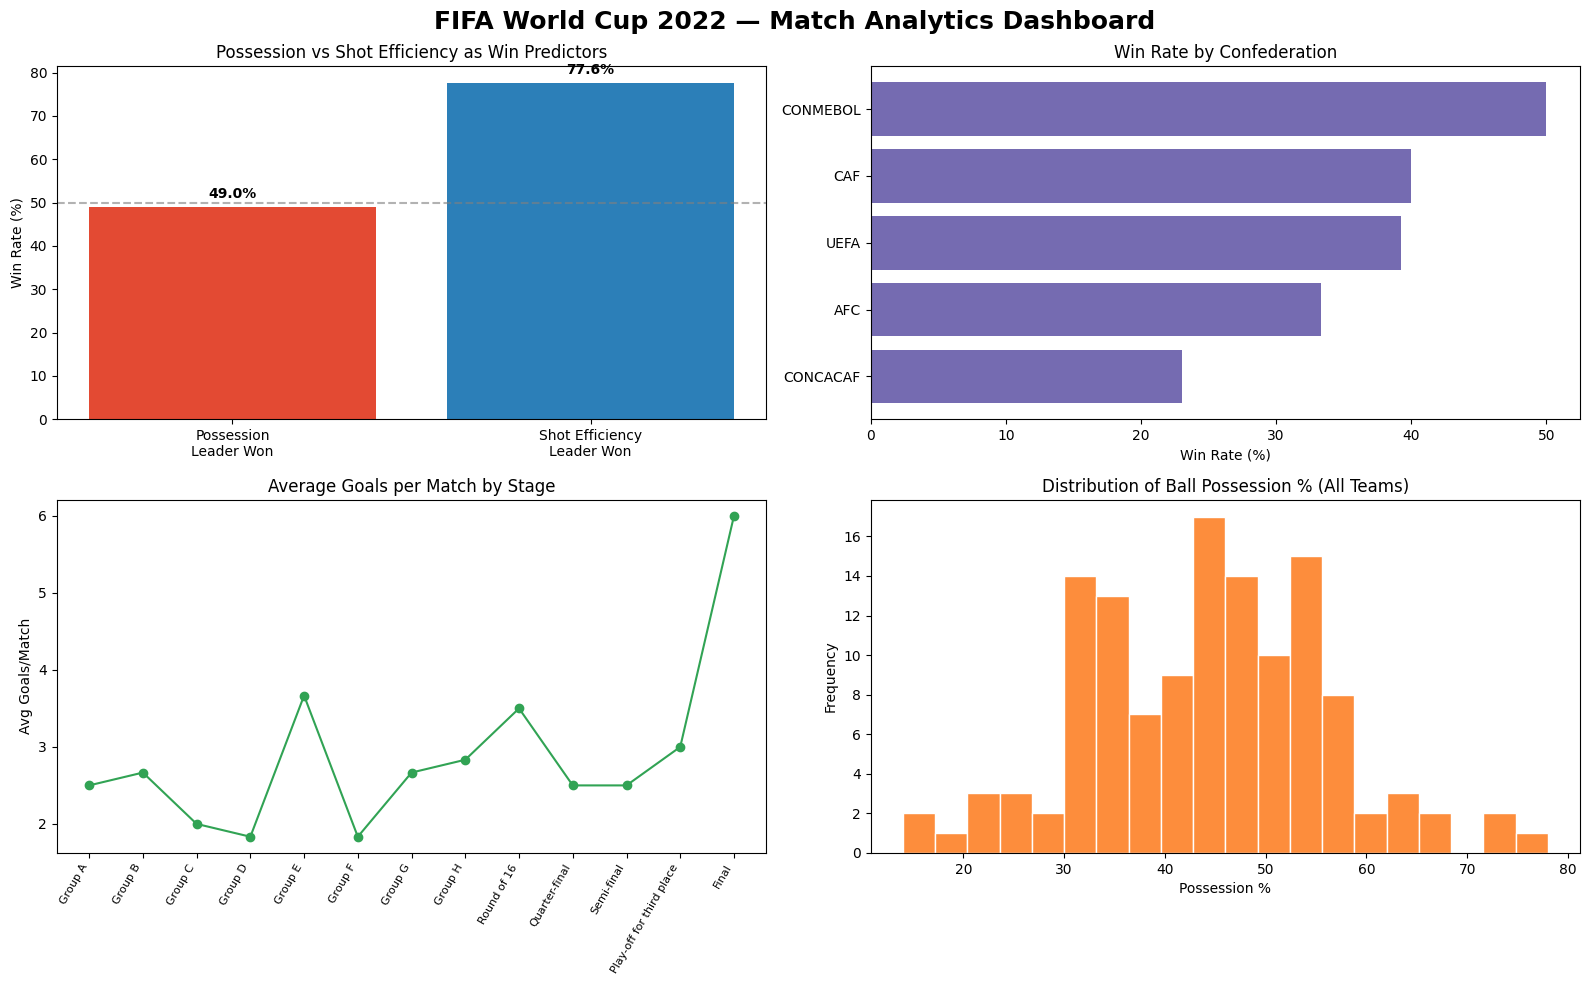

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16,10))
fig.suptitle('FIFA World Cup 2022 — Match Analytics Dashboard', fontsize=18, fontweight='bold')

# 1. Possession vs efficiency as win predictors
labels = ['Possession\nLeader Won', 'Shot Efficiency\nLeader Won']
values = [decisive_matches['possession_leader_won'].mean()*100, decisive_matches['efficiency_leader_won'].mean()*100]
axes[0,0].bar(labels, values, color=['#e34a33','#2c7fb8'])
axes[0,0].axhline(50, color='gray', linestyle='--', alpha=0.6)
axes[0,0].set_title('Possession vs Shot Efficiency as Win Predictors')
axes[0,0].set_ylabel('Win Rate (%)')
for i,v in enumerate(values):
    axes[0,0].text(i, v+2, f'{v:.1f}%', ha='center', fontweight='bold')

# 2. Win rate by confederation
win_by_conf = all_results.groupby('confederation')['won'].mean().sort_values(ascending=False)*100
axes[0,1].barh(win_by_conf.index[::-1], win_by_conf.values[::-1], color='#756bb1')
axes[0,1].set_title('Win Rate by Confederation')
axes[0,1].set_xlabel('Win Rate (%)')

# 3. Goals per match over tournament stages
stage_order = ['Group A','Group B','Group C','Group D','Group E','Group F','Group G','Group H',
               'Round of 16','Quarter-final','Semi-final','Play-off for third place','Final']
df['total_goals'] = df['number of goals team1'] + df['number of goals team2']
avg_goals = df.groupby('category')['total_goals'].mean().reindex(stage_order)
axes[1,0].plot(range(len(avg_goals)), avg_goals.values, marker='o', color='#31a354')
axes[1,0].set_xticks(range(len(avg_goals)))
axes[1,0].set_xticklabels(avg_goals.index, rotation=60, ha='right', fontsize=8)
axes[1,0].set_title('Average Goals per Match by Stage')
axes[1,0].set_ylabel('Avg Goals/Match')

# 4. Possession distribution
axes[1,1].hist(df['possession team1'].tolist()+df['possession team2'].tolist(), bins=20, color='#fd8d3c', edgecolor='white')
axes[1,1].set_title('Distribution of Ball Possession % (All Teams)')
axes[1,1].set_xlabel('Possession %')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('wc2022_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()